# **作业 10 - 对抗攻击**

课件： https://reurl.cc/v5kXkk

Video(En): https://youtu.be/313TZsUDQ48

Video(Zh): https://youtu.be/xWHpPEvkDiE

助教： ntu-ml-2021spring-ta@googlegroups.com

## 环境配置 & 下载

使用 [pytorchcv](https://pypi.org/project/pytorchcv/) 获取 CIFAR-10 预训练模型，需要先配置环境。同时下载要攻击的数据（200 张图片）。

In [11]:
# # 配置环境
# # !pip install pytorchcv

# # 下载
# !gdown 1fHi1ko7wr80wXkXpqpqpOxuYH1mClXoX -O data.zip

# # 解压
# !unzip ./data.zip
# !rm ./data.zip

## 全局设置

* $\epsilon$ 固定为 8。但在**数据部分**，会先通过 **ToTensor（缩放到 0-1）**对原始像素值（0-255）进行变换，再通过 **Normalize（减均值除标准差）**。攻击时 $\epsilon$ 应设为 $\frac{8}{255 * std}$。

* 解释（可选）
    * 设原始图的第一个像素为 $p$，对抗图的第一个像素为 $a$。
    * $\epsilon$ 约束告诉我们 $\left| p-a \right| <= 8$。
    * ToTensor() 可看作函数 $T(x) = x/255$。
    * Normalize() 可看作函数 $N(x) = (x-mean)/std$，其中 $mean$ 和 $std$ 是常数。
    * 对 $p$ 和 $a$ 分别应用 ToTensor() 和 Normalize() 后，约束变为 $\left| N(T(p))-N(T(a)) \right| = \left| \frac{\frac{p}{255}-mean}{std}-\frac{\frac{a}{255}-mean}{std} \right| = \frac{1}{255 * std} \left| p-a \right| <= \frac{8}{255 * std}.$
    * 因此，经过 ToTensor() 和 Normalize() 后，$\epsilon$ 应设为 $\frac{8}{255 * std}$。

In [12]:
import os
import glob
import shutil
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from PIL import Image
from torchvision.transforms import transforms
from torch.utils.data import Dataset, DataLoader
from pytorchcv.model_provider import get_model as ptcv_get_model

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

batch_size = 8

# CIFAR-10 数据集的均值和标准差
cifar_10_mean = (0.491, 0.482, 0.447)  # CIFAR-10 三个通道的均值
cifar_10_std = (0.202, 0.199, 0.201)    # CIFAR-10 三个通道的标准差

# 将均值和标准差转为三维张量以便后续运算
mean = torch.tensor(cifar_10_mean).to(device).view(3, 1, 1)
std = torch.tensor(cifar_10_std).to(device).view(3, 1, 1)

epsilon = 8/255/std
# 迭代式 FGSM 攻击
# alpha（步长）可自行设定
alpha = 0.8/255/std

root = './data'  # 存储良性图片的目录
# 良性图片：不含对抗扰动的图片
# 对抗图片：包含对抗扰动的图片

## 数据

从根目录构建数据集和数据加载器。注意保存每张图片的文件名以供后续使用。

In [13]:
transform = transforms.Compose(
    [transforms.ToTensor(), transforms.Normalize(cifar_10_mean, cifar_10_std)]
)


class AdvDataset(Dataset):
    def __init__(self, data_dir, transform):
        self.images = []
        self.labels = []
        self.names = []
        """
        data_dir
        ├── class_dir
        │   ├── class1.png
        │   ├── ...
        │   ├── class20.png
        """
        for i, class_dir in enumerate(sorted(glob.glob(f"{data_dir}/*"))):
            images = sorted(glob.glob(f"{class_dir}/*"))
            self.images += images
            self.labels += [i] * len(images)
            self.names += [os.path.relpath(imgs, data_dir) for imgs in images]
        self.transform = transform

    def __getitem__(self, idx):
        image = self.transform(Image.open(self.images[idx]))
        label = self.labels[idx]
        return image, label

    def __getname__(self):
        return self.names

    def __len__(self):
        return len(self.images)


adv_set = AdvDataset(root, transform=transform)
adv_names = adv_set.__getname__()
adv_loader = DataLoader(adv_set, batch_size=batch_size, shuffle=False)

print(f"图片数量 = {adv_set.__len__()}")

图片数量 = 200


## 工具函数 -- 良性图片评估

In [14]:
# 评估模型在良性图片上的性能
def epoch_benign(model, loader, loss_fn):
    model.eval()
    train_acc, train_loss = 0.0, 0.0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        yp = model(x)
        loss = loss_fn(yp, y)
        train_acc += (yp.argmax(dim=1) == y).sum().item()
        train_loss += loss.item() * x.shape[0]
    return train_acc / len(loader.dataset), train_loss / len(loader.dataset)

## 工具函数 -- 攻击算法

In [15]:
# 执行 FGSM 攻击
def fgsm(model, x, y, loss_fn, epsilon=epsilon):
    x_adv = x.detach().clone()  # 初始化对抗图为原始良性图
    x_adv.requires_grad = True  # 需要计算 x_adv 的梯度
    loss = loss_fn(model(x_adv), y)  # 计算损失
    loss.backward()  # 计算梯度
    # FGSM: 对 x_adv 做梯度上升以最大化损失
    x_adv = x_adv + epsilon * x_adv.grad.detach().sign()
    return x_adv


# 迭代式 FGSM 攻击：分多步小步走，每步裁剪回 epsilon 邻域
def ifgsm(model, x, y, loss_fn, epsilon=epsilon, alpha=alpha, num_iter=20):
    x_adv = x.detach().clone()  # 初始化对抗图为原始良性图
    for _ in range(num_iter):
        x_adv = fgsm(model, x_adv, y, loss_fn, epsilon=alpha)  # 小步梯度上升
        x_adv = torch.clamp(x_adv, x - epsilon, x + epsilon)   # 裁剪回 [x-epsilon, x+epsilon]
        x_adv = x_adv.detach()                                   # 切断计算图
    return x_adv

## 工具函数 -- 攻击

* 回顾
    * ToTensor() 可看作函数 $T(x) = x/255$。
    * Normalize() 可看作函数 $N(x) = (x-mean)/std$，其中 $mean$ 和 $std$ 是常数。

* 逆函数
    * 逆 Normalize() 可看作函数 $N^{-1}(x) = x*std+mean$，其中 $mean$ 和 $std$ 是常数。
    * 逆 ToTensor() 可看作函数 $T^{-1}(x) = x*255$。

* 特别注意
    * ToTensor() 会将图像从 (height, width, channel) 转为 (channel, height, width)，所以需要转置回原始形状。
    * 由于 dataloader 按 batch 采样，需要用 np.transpose 将 **(batch_size, channel, height, width)** 转置回 **(batch_size, height, width, channel)**。

In [16]:
# 执行对抗攻击并生成对抗样本
def gen_adv_examples(model, loader, attack, loss_fn):
    model.eval()
    adv_names = []
    train_acc, train_loss = 0.0, 0.0
    for i, (x, y) in enumerate(loader):
        x, y = x.to(device), y.to(device)
        x_adv = attack(model, x, y, loss_fn) # 生成对抗样本
        yp = model(x_adv)
        loss = loss_fn(yp, y)
        train_acc += (yp.argmax(dim=1) == y).sum().item()
        train_loss += loss.item() * x.shape[0]
        # 存储对抗样本
        adv_ex = ((x_adv) * std + mean).clamp(0, 1) # 缩放到 0-1
        adv_ex = (adv_ex * 255).clamp(0, 255) # 缩放到 0-255
        adv_ex = adv_ex.detach().cpu().data.numpy().round() # 取整去除小数部分
        adv_ex = adv_ex.transpose((0, 2, 3, 1)) # 将 (bs, C, H, W) 转置回 (bs, H, W, C)
        adv_examples = adv_ex if i == 0 else np.r_[adv_examples, adv_ex]
    return adv_examples, train_acc / len(loader.dataset), train_loss / len(loader.dataset)

# 创建存储对抗样本的目录
def create_dir(data_dir, adv_dir, adv_examples, adv_names):
    if os.path.exists(adv_dir) is not True:
        _ = shutil.copytree(data_dir, adv_dir)
    for example, name in zip(adv_examples, adv_names):
        im = Image.fromarray(example.astype(np.uint8)) # 像素值应为无符号整数
        im.save(os.path.join(adv_dir, name))

## 模型 / 损失函数

模型列表见[此处](https://github.com/osmr/imgclsmob/blob/master/pytorch/pytorchcv/model_provider.py)。请选择带 _cifar10 后缀的模型。部分模型可能无法访问/加载，可以跳过，因为助教的模型不会使用这些模型。

In [17]:
model = ptcv_get_model('resnet110_cifar10', pretrained=True).to(device)
loss_fn = nn.CrossEntropyLoss()

benign_acc, benign_loss = epoch_benign(model, adv_loader, loss_fn)
print(f'良性准确率 = {benign_acc:.5f}, 良性损失 = {benign_loss:.5f}')

良性准确率 = 0.95000, 良性损失 = 0.22678


## FGSM

In [18]:
adv_examples, fgsm_acc, fgsm_loss = gen_adv_examples(model, adv_loader, fgsm, loss_fn)
print(f'FGSM准确率 = {fgsm_acc:.5f}, FGSM损失 = {fgsm_loss:.5f}')

create_dir(root, 'fgsm', adv_examples, adv_names)

FGSM准确率 = 0.59000, FGSM损失 = 2.49246


## I-FGSM

In [19]:
adv_examples, ifgsm_acc, ifgsm_loss = gen_adv_examples(model, adv_loader, ifgsm, loss_fn)
print(f'I-FGSM准确率 = {ifgsm_acc:.5f}, I-FGSM损失 = {ifgsm_loss:.5f}')

create_dir(root, 'ifgsm', adv_examples, adv_names)

I-FGSM准确率 = 0.00500, I-FGSM损失 = 17.36974


## 压缩图片

In [20]:
%cd fgsm
!tar zcvf ../fgsm.tgz *
%cd ..

%cd ifgsm
!tar zcvf ../ifgsm.tgz *
%cd ..

/Users/Learning/AI/DeepAndReinforced/experiments/ML2021-Spring/HW10/fgsm
a airplane
a airplane/airplane9.png
a airplane/airplane8.png
a airplane/airplane20.png
a airplane/airplane19.png
a airplane/airplane18.png
a airplane/airplane15.png
a airplane/airplane14.png
a airplane/airplane16.png
a airplane/airplane17.png
a airplane/airplane13.png
a airplane/airplane12.png
a airplane/airplane10.png
a airplane/airplane11.png
a airplane/airplane1.png
a airplane/airplane3.png
a airplane/airplane2.png
a airplane/airplane6.png
a airplane/airplane7.png
a airplane/airplane5.png
a airplane/airplane4.png
a automobile
a automobile/automobile3.png
a automobile/automobile2.png
a automobile/automobile1.png
a automobile/automobile5.png
a automobile/automobile4.png
a automobile/automobile6.png
a automobile/automobile7.png
a automobile/automobile17.png
a automobile/automobile16.png
a automobile/automobile14.png
a automobile/automobile15.png
a automobile/automobile11.png
a automobile/automobile10.png
a automob

## 可视化

/var/folders/zm/yjlbch017pb6k0b5ljtn_k5h0000gn/T/ipykernel_87471/2864513940.py:27: UserWarning: Glyph 33391 (\N{CJK UNIFIED IDEOGRAPH-826F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/zm/yjlbch017pb6k0b5ljtn_k5h0000gn/T/ipykernel_87471/2864513940.py:27: UserWarning: Glyph 24615 (\N{CJK UNIFIED IDEOGRAPH-6027}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/zm/yjlbch017pb6k0b5ljtn_k5h0000gn/T/ipykernel_87471/2864513940.py:27: UserWarning: Glyph 23545 (\N{CJK UNIFIED IDEOGRAPH-5BF9}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/zm/yjlbch017pb6k0b5ljtn_k5h0000gn/T/ipykernel_87471/2864513940.py:27: UserWarning: Glyph 25239 (\N{CJK UNIFIED IDEOGRAPH-6297}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/Learning/AI/DeepAndReinforced/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 33391 (\N{CJK UNIFIED IDEOGRAPH-826F}) missing from font(s) DejaVu Sans.
  fig.canvas.print_f

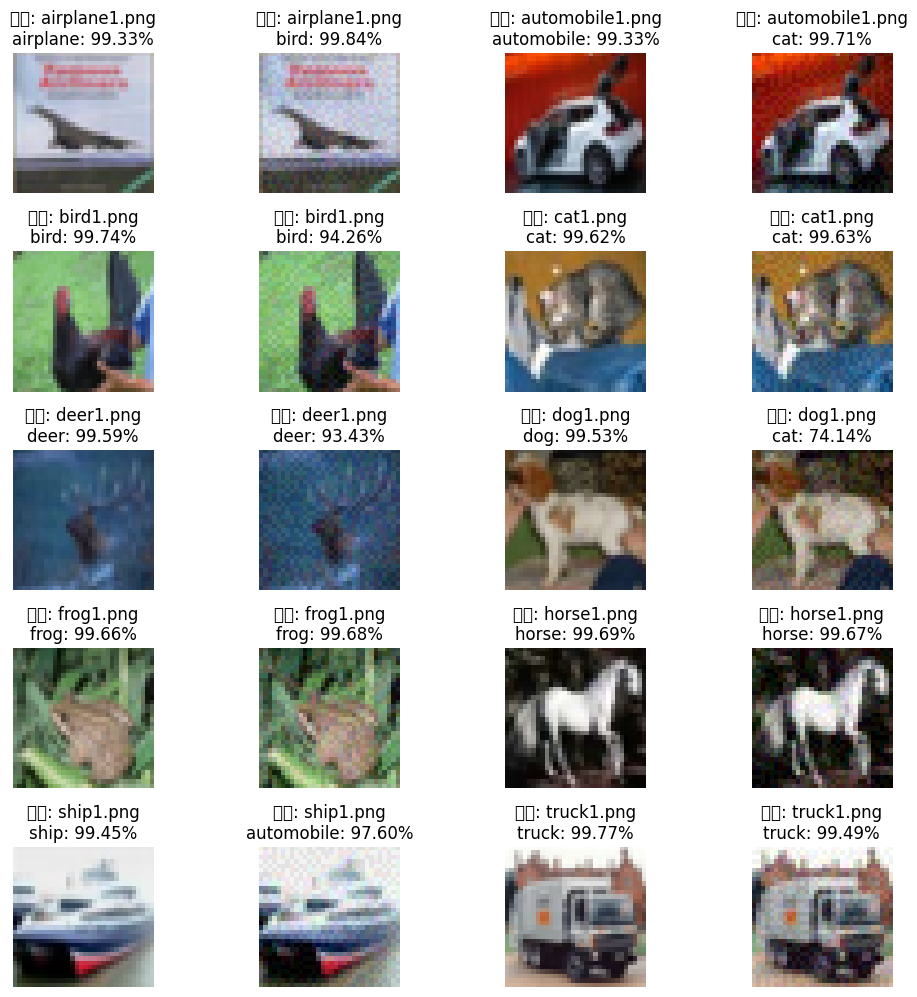

In [21]:
classes = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

plt.figure(figsize=(10, 20))
cnt = 0
for i, cls_name in enumerate(classes):
    path = f'{cls_name}/{cls_name}1.png'
    # 良性图片
    cnt += 1
    plt.subplot(len(classes), 4, cnt)
    im = Image.open(f'./data/{path}')
    logit = model(transform(im).unsqueeze(0).to(device))[0]
    predict = logit.argmax(-1).item()
    prob = logit.softmax(-1)[predict].item()
    plt.title(f'良性: {cls_name}1.png\n{classes[predict]}: {prob:.2%}')
    plt.axis('off')
    plt.imshow(np.array(im))
    # 对抗图片
    cnt += 1
    plt.subplot(len(classes), 4, cnt)
    im = Image.open(f'./fgsm/{path}')
    logit = model(transform(im).unsqueeze(0).to(device))[0]
    predict = logit.argmax(-1).item()
    prob = logit.softmax(-1)[predict].item()
    plt.title(f'对抗: {cls_name}1.png\n{classes[predict]}: {prob:.2%}')
    plt.axis('off')
    plt.imshow(np.array(im))
plt.tight_layout()
plt.show()